# TP1 PROCESAMIENTO DEL HABLA: webscrapping

**Crea una copia de este notebook en tu google colab**

**Renombra el notebook con el siguiente formato APELLIDO_NOMBRE_PH_TP1.ipynb**

**[Emiliano Abraham]**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [1]:
import requests
from bs4 import BeautifulSoup

url = "https://ecosistemastartup.com/sam-altman-advierte-la-sociedad-y-la-ia-evolucionaran-juntas/"

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/152.0.0.0 Safari/537.36"}
respuesta = requests.get(url, headers=headers)

print(respuesta.status_code)

#La pagina bloquea la solicitud que mandamos para obtener el html, esto debe que a que tiene algun bloqueador que no lo permite
#Por ende voy a usar Selenium para simular que la peticion la realiza un navegador real

403


In [2]:
!pip install google-colab-Selenium

In [4]:
import google_colab_selenium as gs
import time

In [5]:
driver = gs.Chrome()

driver.get(url)
time.sleep(15)

print(driver.title)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Just a moment...


inicialmente intente scrapear una nota de El Ecosistema Startup, pero el sitio está protegido por Cloudflare y bloqueó tanto requests (error 403) como Selenium (pantalla "Just a moment...").
Por eso elegi la traducción completa de su ensayo "La singularidad suave", que está íntegramente en sus palabras y se puede descargar sin bloqueos.

In [6]:
url = "https://accionables.substack.com/p/la-singularidad-suave-sam-altman"

respuesta = requests.get(url)
print(respuesta.status_code)

200


In [7]:
soup = BeautifulSoup(respuesta.text, "html.parser")

contenedor = soup.select_one("div.body.markup") #Busco el contenedor del post

parrafos = contenedor.find_all("p")
print(len(parrafos)) #Cuantos parrafos encontro

57


In [8]:
for h in soup.find_all("h1"):
    print(h.get("class"), "→", h.get_text(strip=True))

['pencraft', 'pc-reset', 'font-pub-headings-FE5byy', 'reset-IxiVJZ', 'title-oOnUGd'] → David Macías (Accionables IA)
['post-title', 'published', 'title-X77sOw'] → La singularidad suave (Sam Altman)


In [9]:
titulo = soup.find("h1", class_="post-title").get_text(strip=True)
print(titulo)

La singularidad suave (Sam Altman)


In [10]:
texto = " ".join(p.get_text(strip=True) for p in parrafos)
print(len(texto))
print(texto)

10928
 “Ya hemos pasado el horizonte de eventos; el despegue ha comenzado. La humanidad está cerca de construir una superinteligencia digital, y al menos por ahora, es mucho menos extraña de lo que parece que debería ser.  Los robots aún no caminan por las calles, ni la mayoría de nosotros pasamos el día hablando con una IA. La gente todavía muere por enfermedades, aún no podemos ir fácilmente al espacio, y todavía hay muchas cosas del universo que no entendemos.  Y sin embargo, recientemente hemos creado sistemas que son más inteligentes que las personas en muchos sentidos, y que son capaces de amplificar significativamente la producción de quienes los usan. La parte menos probable del trabajo ya ha quedado atrás; los descubrimientos científicos que nos llevaron a sistemas como GPT-4 y o3 fueron difíciles de conseguir, pero nos llevarán muy lejos.  La IA contribuirá al mundo de muchas maneras, pero las mejoras en la calidad de vida gracias al progreso científico más rápido y a una may

In [11]:
for i, p in enumerate(parrafos):
    print(i, "→", p.get_text(strip=True)[:80])


0 → 
1 → “Ya hemos pasado el horizonte de eventos; el despegue ha comenzado. La humanidad
2 → 
3 → Los robots aún no caminan por las calles, ni la mayoría de nosotros pasamos el d
4 → 
5 → Y sin embargo, recientemente hemos creado sistemas que son más inteligentes que 
6 → 
7 → La IA contribuirá al mundo de muchas maneras, pero las mejoras en la calidad de 
8 → 
9 → En un sentido importante, ChatGPT ya es más poderoso que cualquier humano que ha
10 → 
11 → El 2025 ha traído la llegada de agentes que pueden realizar trabajo cognitivo re
12 → 
13 → Muchas más personas podrán crear software y arte. Pero el mundo quiere mucho más
14 → 
15 → En los aspectos más importantes, los años 2030 quizá no sean tan diferentes. La 
16 → 
17 → Pero en otros aspectos —también muy importantes—, los años 2030 probablemente se
18 → 
19 → En los años 2030, la inteligencia y la energía —las ideas, y la capacidad de lle
20 → 
21 → Ya vivimos con una inteligencia digital increíble, y después de un pequeño shoc

In [12]:
parrafos_limpios = []

for p in parrafos:
    contenido = p.get_text(strip=True)
    if contenido != "" and contenido != "Subscribe":
        parrafos_limpios.append(contenido)

print(len(parrafos_limpios))
print(parrafos_limpios[-1])

28
Que escalemos con suavidad, exponencialmente y sin sobresaltos hacia la superinteligencia.”


In [13]:
texto = titulo + ". " + " ".join(parrafos_limpios)
print(len(texto))
print(texto[:150])

10926
La singularidad suave (Sam Altman). “Ya hemos pasado el horizonte de eventos; el despegue ha comenzado. La humanidad está cerca de construir una super


### Extracción del texto

Se descargó la página con `requests` (status 200) y se parseó con BeautifulSoup. El ensayo está dentro del `div` con clases `body markup`, del cual se extrajeron los párrafos (`<p>`). Al revisarlos se detectaron párrafos vacíos y el botón "Subscribe", que se filtraron.
El resultado son 28 párrafos unidos en un único texto de 10.890 caracteres.

## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

In [14]:
import nltk #Importo la libreria NLTK y descargo la herramienta para detectar stopwords
nltk.download("stopwords")

from nltk.corpus import stopwords
stopwords_es = set(stopwords.words("spanish")) #Le indico a la libreria que el texto esta en espanol


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [15]:
#separo el texto en palabras
import re

palabras = re.findall(r"\w+", texto.lower())
print(len(palabras))

1719


In [16]:
#Identifico la cantidad de stopwords
n_stopwords = [p for p in palabras if p in stopwords_es]

#Las muestro sin repetir
stopwords_unicas = sorted(set(n_stopwords))

print("Cantidad de StopWords:")
print(len(n_stopwords))

print("Cantidad de StopWords unicas:")
print(len(stopwords_unicas))
print(stopwords_unicas)

Cantidad de StopWords:
764
Cantidad de StopWords unicas:
97
['a', 'al', 'algo', 'algunas', 'antes', 'como', 'con', 'cuando', 'de', 'del', 'desde', 'donde', 'durante', 'el', 'en', 'eran', 'es', 'esos', 'esta', 'estamos', 'estaremos', 'estaríamos', 'estas', 'esto', 'estos', 'está', 'están', 'fueron', 'ha', 'habremos', 'habrá', 'habrán', 'habría', 'han', 'hay', 'haya', 'hemos', 'hubiéramos', 'la', 'las', 'lo', 'los', 'me', 'mucho', 'muchos', 'muy', 'más', 'nada', 'ni', 'no', 'nos', 'nosotros', 'nuestras', 'o', 'otra', 'otras', 'otro', 'otros', 'para', 'pero', 'poco', 'por', 'porque', 'que', 'quienes', 'qué', 'se', 'sea', 'sean', 'sentido', 'sentidos', 'será', 'serán', 'sin', 'sobre', 'somos', 'son', 'su', 'sus', 'también', 'tanto', 'te', 'tendríamos', 'tenemos', 'tengo', 'tenían', 'tienen', 'todo', 'todos', 'tu', 'tus', 'un', 'una', 'unos', 'y', 'ya', 'él']


In [17]:
#Porcentaje de stopwords
print(len(palabras))
print(round(len(n_stopwords) / len(palabras) * 100, 1), "%")

1719
44.4 %


### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

La eliminación de caracteres extraños ya quedó resuelta al tokenizar con `re.findall(r"\w+", texto.lower())`: el patrón `\w+` solo captura letras y números, por lo que descarta puntuación, comillas tipográficas, guiones largos y paréntesis.

In [18]:
palabras_filtradas = [
    p for p in palabras
    if p not in stopwords_es and not p.isdigit() and len(p) > 1
]

print(len(palabras_filtradas))

934


In [19]:
#Rearmo el texto limpio
texto_limpio = " ".join(palabras_filtradas)
print(texto_limpio)

singularidad suave sam altman pasado horizonte eventos despegue comenzado humanidad cerca construir superinteligencia digital menos ahora menos extraña parece debería ser robots aún caminan calles mayoría pasamos día hablando ia gente todavía muere enfermedades aún podemos ir fácilmente espacio todavía muchas cosas universo entendemos embargo recientemente creado sistemas inteligentes personas capaces amplificar significativamente producción usan parte menos probable trabajo quedado atrás descubrimientos científicos llevaron sistemas gpt o3 difíciles conseguir llevarán lejos ia contribuirá mundo muchas maneras mejoras calidad vida gracias progreso científico rápido mayor productividad enormes futuro puede ser mejor presente progreso científico mayor impulsor progreso general emocionante pensar cuánto podríamos tener importante chatgpt poderoso cualquier humano existido cientos millones personas dependen cada día tareas cada vez importantes capacidad nueva pequeña puede tener impacto en

In [20]:
#Importo las librerias necesarias para realizar la nube de palabras
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [21]:
#Creo la nube de palabras
nube = WordCloud(
    width=800,
    height=400,
    background_color="white",
    collocations=False #Evita que se junten palabras que se repiten constantemente ("Inteligencia Artificial")
                       #como una oracion y muestre las palabras por separado
 ).generate(texto_limpio)

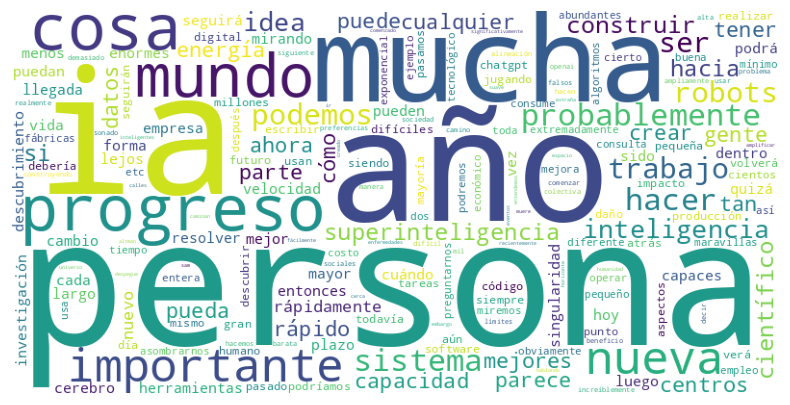

In [22]:
#Mostrar nube
plt.figure(figsize=(10, 5))
plt.imshow(nube)
plt.axis("off")
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).


#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


In [23]:
nltk.download("punkt_tab") #Tokenizador de oraciones.

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [24]:
from nltk.tokenize import sent_tokenize #Tokeniza las oraciones por puntos pero no estrictamente ya que 0.34 no indica el fin de una oracion

oraciones = sent_tokenize(texto, language="spanish")
print(len(oraciones))

76


In [25]:
for i, o in enumerate(oraciones[:5]): #Test para ver si las primeras 5 oraciones quedaron bien
    print(i, "→", o)

0 → La singularidad suave (Sam Altman).
1 → “Ya hemos pasado el horizonte de eventos; el despegue ha comenzado.
2 → La humanidad está cerca de construir una superinteligencia digital, y al menos por ahora, es mucho menos extraña de lo que parece que debería ser.
3 → Los robots aún no caminan por las calles, ni la mayoría de nosotros pasamos el día hablando con una IA.
4 → La gente todavía muere por enfermedades, aún no podemos ir fácilmente al espacio, y todavía hay muchas cosas del universo que no entendemos.


In [26]:
#Armar el vectorizador
#Importar funcion para vectorizar
from sklearn.feature_extraction.text import CountVectorizer

vectorizador = CountVectorizer(stop_words=list(stopwords_es)) #Le paso la lista de las stopwords que utilice antes

In [27]:
matriz = vectorizador.fit_transform(oraciones) #Creamos la matriz, fit arma el vocabulario, conteo de palabras distintas y transform cuenta cantas veces aparece cada palabra del vocabulario en cada oracion

#Ver matriz como tabla
import pandas as pd
df = pd.DataFrame(
    matriz.toarray(),
    columns=vectorizador.get_feature_names_out()
)
df.head(5)

,000085,2020,2025,2026,2027,2030,2035,34,abundantes,acceso,...,viviendo,vivimos,vivirlo,voluntad,volverá,volverán,vuelven,áreas,época,últimos
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



#### 2.3.2 Determina la longitud de tu vocabulario.

In [28]:
#Obtengo el vocabulario
vocabulario = vectorizador.get_feature_names_out() #Devuele las palabras que aparecen en el texto pero una sola vez.
print(len(vocabulario))

605


In [29]:
print(vocabulario[:30])
print(vocabulario[-30:])

['000085' '2020' '2025' '2026' '2027' '2030' '2035' '34' 'abundantes'
 'acceso' 'acelerándose' 'acostumbrados' 'actuales' 'actualice' 'actúen'
 'adapta' 'adaptaremos' 'adaptarse' 'adelante' 'adoptemos' 'adopten'
 'agentes' 'agi' 'agradecidos' 'agricultor' 'agua' 'ahora' 'alcance'
 'algoritmos' 'alineación']
['unas' 'universo' 'usa' 'usan' 'usar' 'usarla' 'usuarios' 'valor'
 'vatios' 'veces' 'velocidad' 'ventaja' 'verdadera' 'versión' 'versus'
 'vertical' 'verá' 'vez' 'vida' 'vidas' 'viviendo' 'vivimos' 'vivirlo'
 'voluntad' 'volverá' 'volverán' 'vuelven' 'áreas' 'época' 'últimos']



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [30]:
from sklearn.feature_extraction.text import TfidfTransformer

transformador = TfidfTransformer()
matriz_tfidf = transformador.fit_transform(matriz)
print(matriz_tfidf.shape)

(76, 605)


In [31]:
#Mostrar la matriz TF-IDF
df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    columns=vectorizador.get_feature_names_out()
)
df_tfidf.head()

,000085,2020,2025,2026,2027,2030,2035,34,abundantes,acceso,...,viviendo,vivimos,vivirlo,voluntad,volverá,volverán,vuelven,áreas,época,últimos
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
print(oraciones[1])

fila = df_tfidf.iloc[1]
print(fila[fila > 0].sort_values(ascending=False).head(10))

“Ya hemos pasado el horizonte de eventos; el despegue ha comenzado.
comenzado    0.454864
despegue     0.454864
eventos      0.454864
horizonte    0.454864
pasado       0.415207
Name: 1, dtype: float64


In [33]:
print(matriz_tfidf.nnz)
print(round(matriz_tfidf.nnz / (matriz_tfidf.shape[0] * matriz_tfidf.shape[1]) * 100, 2), "%")

902
1.96 %


Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

Se aplicó TF-IDF sobre la matriz de conteos con `TfidfTransformer`, manteniendo las mismas dimensiones (oraciones × vocabulario) pero reemplazando los conteos enteros por pesos decimales.

El peso combina la frecuencia del término en la oración (TF) con la inversa de su frecuencia en el conjunto de oraciones (IDF): una palabra que aparece en pocas oraciones recibe mayor peso porque resulta más distintiva.

# Conclusiones

La primera página elegida estaba protegida por Cloudflare y bloqueó tanto a `requests` como a Selenium.
La segunda fue accesible sin necesidad de simular un navegador. También quedó claro que extraer el contenedor correcto no alcanza: al revisar los párrafos uno por uno aparecieron elementos de la interfaz del sitio (el botón "Subscribe" y separadores vacíos) que había que filtrar.

El 44,4% de las palabras del texto resultaron ser stopwords, casi la mitad. Sin removerlas, la nube habría mostrado "de", "que" y "la" en primer plano, sin ningún valor informativo.

La matriz resultante tiene 76 filas (una por oración) y 605 columnas (una por término del vocabulario). Es una matriz dispersa: solo el 1,96% de las celdas es distinto de cero, porque cada oración usa apenas un puñado de las palabras disponibles. Por eso scikit-learn la almacena en formato comprimido.

**TF-IDF:** La transformación conserva las dimensiones de la matriz pero reemplaza los conteos por pesos que reflejan cuán distintiva es cada palabra: las que aparecen en pocas oraciones pesan más. Esto permite identificar los términos característicos de cada oración, algo que el conteo crudo no distingue.

**Conclusion general:.** El preprocesamiento no es un paso mecánico previo al análisis: cada decisión (qué filtrar, qué considerar una oración, qué lista de stopwords usar) modifica el resultado final. Un texto que para una persona es una idea se convierte, tras este proceso, en una matriz numérica que un modelo puede procesar, y la calidad de esa matriz depende enteramente de las decisiones tomadas en el camino.


# Anexo, código de ejemplo del uso de wordcloud

Instalar e importar la librería

In [34]:
# instalar wordcloud
!pip install wordcloud


In [35]:

# Importar librerías
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [36]:

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Crear un objeto WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)


Mostramos la imagen generada

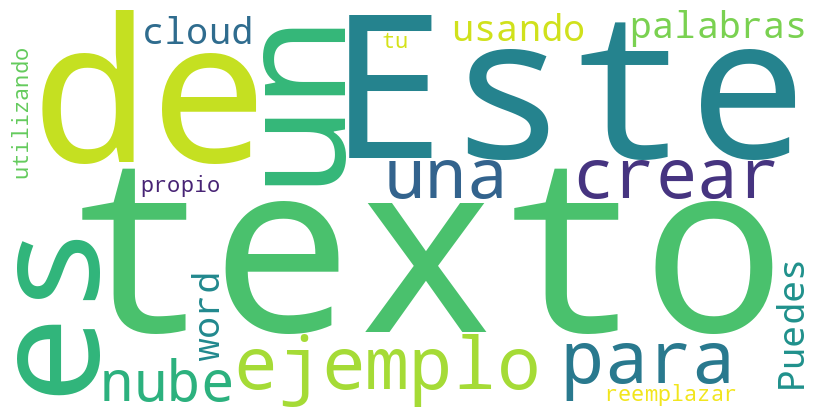

In [37]:

# mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

Modificamos el ejemplo anterior agregando palabras en español que no queremos que considere para crear la nube de palabras. Estas son las stop_words



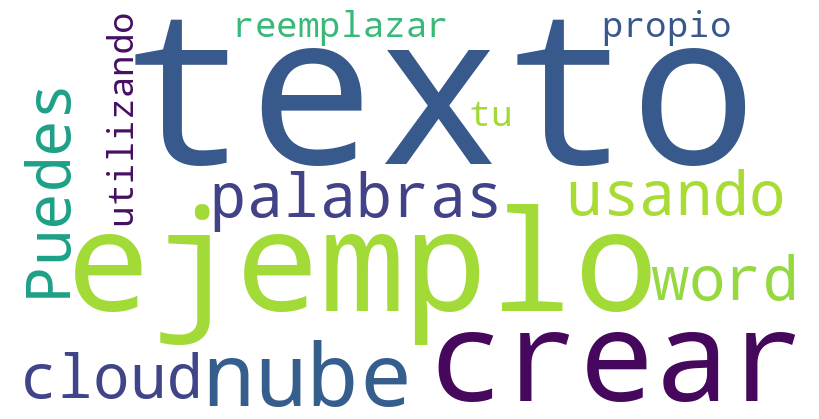

In [38]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Definir stopwords en español
stopwords_es = set(STOPWORDS)
stopwords_es.update(["con", "que", "los", "para", "un", "una", "el", "la", "en", "y", "o", "de", "a", "se", "es", "al", "como", "por", "no", "su", "más", "pero", "si", "este", "esta", "eso", "esa", "todo", "todos", "todas", "cada", "cual", "cualquier", "algo", "alguna", "algún", "ningún", "ninguna", "ninguno", "otro", "otros", "otras", "sobre", "entre", "durante", "desde", "hasta", "también", "así", "mismo", "misma", "mismo", "misma", "tan", "tanto", "tanta", "muy", "poco", "poca", "poco", "nada", "solo", "sola", "solo", "sola", "siempre", "nunca", "jamás", "casi", "aproximadamente", "cerca", "lejos", "antes", "después", "ahora", "hoy", "ayer", "mañana", "luego", "mientras", "mientras tanto", "después de", "antes de", "durante", "sin", "aunque", "a pesar de", "debido a", "gracias a", "por qué", "cómo", "dónde", "cuándo", "quién", "qué", "cuál"])

# Crear un objeto WordCloud con stopwords en español
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_es).generate(text)

# Mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()
